## 1. Введение
Это бразильский открытый набор данных по электронной коммерции, содержащий информацию о заказах, оформленных в магазине Olist Store. Набор данных включает сведения о 100 тыс. заказов за период с 2016 по 2018 год, оформленных на различных торговых площадках Бразилии. Его характеристики позволяют анализировать заказы с разных точек зрения: от статуса заказа, цены, способа оплаты и условий доставки до местоположения покупателя, характеристик товара и, наконец, отзывов, оставленных покупателями.

Это реальные коммерческие данные, они были анонимизированы, а упоминания компаний и партнеров в тексте отзывов заменены названиями великих домов из сериала «Игра престолов».

Модель оценивает риск низкой оценки после фактической доставки заказа, но до публикации клиентом отзыва. Поэтому используются только признаки, известные к моменту доставки, включая фактический срок доставки и отклонение от обещанной даты.

## 2. Предварительный просмотр данных

In [ ]:
#для синхронизации с гугл-драйвом
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#загружаем файл
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/olist_final.csv')

In [ ]:
# размер и смотрим что есть в датасете
print("Shape:", df.shape)
df.head()

Shape: (95832, 24)


,order_id,customer_city,customer_state,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,is_late,item_count,...,main_product_id,main_product_category,main_seller_id,main_seller_state,payment_records,payment_type_count,total_payment_value,primary_payment_type,review_score,low_review
0,e481f51cbdc54678b7cc49136f2d6af7,sao paulo,SP,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,8.44,-7.11,0,1,...,87285b34884572647811a353c7ac498a,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,SP,3.0,2.0,38.71,voucher,4,0
1,53cdb2fc8bc7dce0b6741e2150273451,barreiras,BA,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,13.78,-5.36,0,1,...,595fac2a385ac33a80bd5114aec74eb8,perfumery,289cdb325fb7e7f891c38608bf9e0962,SP,1.0,1.0,141.46,boleto,4,0
2,47770eb9100c2d0c44946d9cf07ec65d,vianopolis,GO,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,9.39,-17.25,0,1,...,aa4383b373c6aca5d8797843e5594415,auto,4869f7a5dfa277a7dca6462dcf3b52b2,SP,1.0,1.0,179.12,credit_card,5,0
3,949d5b44dbf5de918fe9c16f97b45f8a,sao goncalo do amarante,RN,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00,13.21,-12.98,0,1,...,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,66922902710d126a0e7d26b0e3805106,MG,1.0,1.0,72.20,credit_card,5,0
4,ad21c59c0840e6cb83a9ceb5573f8159,santo andre,SP,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00,2.87,-9.24,0,1,...,65266b2da20d04dbe00c5c2d3bb7859e,stationery,2c9e548be18521d1c43cde1c582c6de8,SP,1.0,1.0,28.62,credit_card,5,0


In [ ]:
#проверка уникальности и распределение по столбцу low review
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Unique order_id:", df['order_id'].nunique())
print("Duplicate order_id:", df.duplicated(subset='order_id').sum())

print("\nTarget distribution:")
print(df['low_review'].value_counts())

print("\nMissing values:")
print(df.isna().sum())

Rows: 95832
Columns: 24
Unique order_id: 95832
Duplicate order_id: 0

Target distribution:
low_review
0    83559
1    12273
Name: count, dtype: int64

Missing values:
order_id                            0
customer_city                       0
customer_state                      0
order_purchase_timestamp            0
order_delivered_customer_date       8
order_estimated_delivery_date       0
delivery_days                       8
delay_days                          8
is_late                             0
item_count                          0
unique_products                     0
unique_sellers                      0
total_price                         0
total_freight                       0
main_product_id                     0
main_product_category            1349
main_seller_id                      0
main_seller_state                   0
payment_records                     1
payment_type_count                  1
total_payment_value                 1
primary_payment_type               

In [ ]:
# информация о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95832 entries, 0 to 95831
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       95832 non-null  object 
 1   customer_city                  95832 non-null  object 
 2   customer_state                 95832 non-null  object 
 3   order_purchase_timestamp       95832 non-null  object 
 4   order_delivered_customer_date  95824 non-null  object 
 5   order_estimated_delivery_date  95832 non-null  object 
 6   delivery_days                  95824 non-null  float64
 7   delay_days                     95824 non-null  float64
 8   is_late                        95832 non-null  int64  
 9   item_count                     95832 non-null  int64  
 10  unique_products                95832 non-null  int64  
 11  unique_sellers                 95832 non-null  int64  
 12  total_price                    95832 non-null 

- main_product_category имеет 1349 пропусков;
- order_delivered_customer_date, delivery_days, delay_days — по 8.
- платежные признаки — по 1 пропуску;
- остальные поля практически полные.

In [ ]:
# перевод в формат дат
date_columns = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

df[date_columns].dtypes

,0
order_purchase_timestamp,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [ ]:
# смотрим описательную статистику
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,95832,2018-01-02 03:06:22.835733504,2016-09-15 12:16:38,2017-09-14 10:24:16.249999872,2018-01-20 23:42:15.500000,2018-05-06 00:30:51.500000,2018-08-29 15:00:37,NaN
order_delivered_customer_date,95824,2018-01-14 15:18:39.333496832,2016-10-11 13:46:32,2017-09-26 10:32:23.750000128,2018-02-02 20:45:40.500000,2018-05-16 11:34:45.750000128,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,95832,2018-01-25 20:40:26.145755136,2016-10-04 00:00:00,2017-10-05 00:00:00,2018-02-16 00:00:00,2018-05-28 00:00:00,2018-10-25 00:00:00,NaN
delivery_days,95824.0,12.51675,0.53,6.76,10.21,15.66,208.35,9.460503
delay_days,95824.0,-11.21521,-146.02,-16.25,-11.97,-6.41,188.98,10.1141
is_late,95832.0,0.079942,0.0,0.0,0.0,0.0,1.0,0.271205
item_count,95832.0,1.141268,1.0,1.0,1.0,1.0,21.0,0.534085
unique_products,95832.0,1.038307,1.0,1.0,1.0,1.0,8.0,0.227191
unique_sellers,95832.0,1.013847,1.0,1.0,1.0,1.0,5.0,0.123373
total_price,95832.0,136.801837,0.85,45.9,86.25,149.9,13440.0,207.780887


In [ ]:
# описание категориальных признаков
df.describe(include='object').T

,count,unique,top,freq
order_id,95832,95832,66dea50a8b16d9b4dee7af250b4be1a5,1
customer_city,95832,4083,sao paulo,14947
customer_state,95832,27,SP,40273
main_product_id,95832,30973,aca2eb7d00ea1a7b8ebd4e68314663af,423
main_product_category,94483,73,bed_bath_table,9080
main_seller_id,95832,2953,6560211a19b47992c3666cc44a7e94c0,1787
main_seller_state,95832,22,SP,67929
primary_payment_type,95831,4,credit_card,72338


In [ ]:
df_eda = df.copy()  # Для анализа доставки исключили 8 строк без даты

delivery_data = df_eda.dropna(
    subset=['delivery_days', 'delay_days']
)

df_eda['main_product_category'] = (
    df_eda['main_product_category'].fillna('unknown')
)

print(df_eda.shape)
print(delivery_data.shape)

(95832, 24)
(95824, 24)


# 3. Вопросы для исследования

Целевая переменная: low_review = 1, если review_score равен 1–2 звёздам, и low_review = 0, если оценка равна 3–5 звёздам. Порог выбран в соответствии с бизнес-задачей проекта, где 1–2 звезды определены как низкая оценка.

## 1 - Как распределена целевая переменная?

In [ ]:
#смотрим таргет столбец
target_counts = df['low_review'].value_counts()
target_percent = df['low_review'].value_counts(normalize=True) * 100

print(target_counts)
print(target_percent.round(2))

low_review
0    83559
1    12273
Name: count, dtype: int64
low_review
0    87.19
1    12.81
Name: proportion, dtype: float64


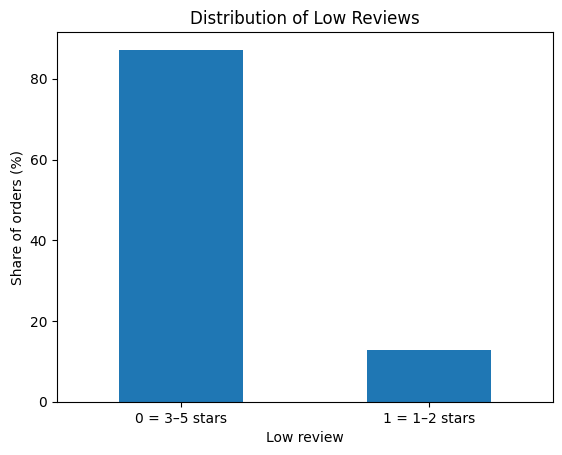

In [ ]:
import matplotlib.pyplot as plt

target_percent.plot(kind='bar')

plt.title('Distribution of Low Reviews')
plt.xlabel('Low review')
plt.ylabel('Share of orders (%)')
plt.xticks(
    ticks=[0, 1],
    labels=['0 = 3–5 stars', '1 = 1–2 stars'],
    rotation=0
)

plt.show()

Низкие оценки составляют 12.81% всех заказов, тогда как 87.19% заказов относятся к классу без низкой оценки. Таким образом, целевая переменная несбалансирована. При оценке моделей поэтому недостаточно ориентироваться только на accuracy; необходимо учитывать метрики, чувствительные к дисбалансу классов.

## 2 - как сроки доставки связаны с низкой оценкой?

In [ ]:
# средние и медианные значения дней доставки и отсроченных дней по доставке
delivery_stats = (
    delivery_data
    .groupby('low_review')[['delivery_days', 'delay_days']]
    .agg(['mean', 'median'])
    .round(2)
)

delivery_stats

delivery_days        delay_days       
                    mean median       mean median
low_review                                       
0                  11.39   9.87     -12.21 -12.19
1                  20.21  15.72      -4.43  -7.25

In [ ]:
#сколько процентов опозданий по низким и нормальным оценкам
late_review_rate = (
    delivery_data
    .groupby('is_late')['low_review']
    .mean()
    .mul(100)
    .round(2)
)

late_review_rate

,low_review
is_late,
0,9.22
1,54.07


- при low_review = 0 доставка занимает в среднем 11.39 дня, медиана 9.87;
- при low_review = 1 — уже 20.21 дня, медиана 15.72;
- заказы без низкой оценки в среднем приходят примерно на 12.21 дня раньше обещанного срока;
- заказы с низкой оценкой — только примерно на 4.43 дня раньше;
- самое показательное: среди заказов, доставленных вовремя, низких оценок 9.22%, а среди опоздавших — 54.07%.

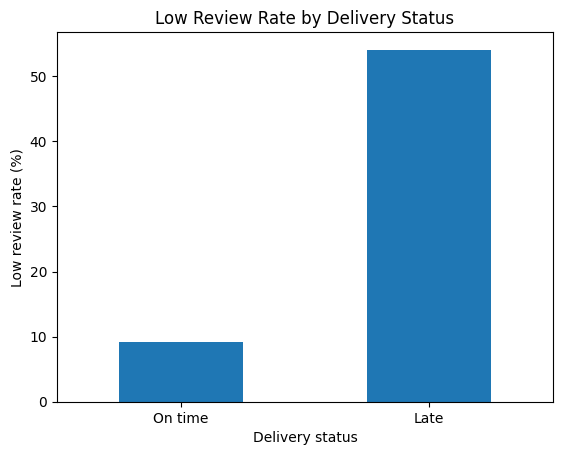

In [ ]:
# график распределения опозданий по оценкам отзывов
late_review_rate.plot(kind='bar')

plt.title('Low Review Rate by Delivery Status')
plt.xlabel('Delivery status')
plt.ylabel('Low review rate (%)')

plt.xticks(
    ticks=[0, 1],
    labels=['On time', 'Late'],
    rotation=0
)

plt.show()

Доля низких оценок среди своевременно доставленных заказов составляет 9.22%, тогда как среди опоздавших заказов она возрастает до 54.07%. Кроме того, заказы с низкой оценкой в среднем доставлялись дольше. Это указывает на сильную связь между сроками доставки и удовлетворённостью клиента.

## 3 - связаны ли стоимость заказа и стоимость доставки с низкой оценкой?

In [ ]:
price_stats = (
    df_eda
    .groupby('low_review')[['total_price', 'total_freight']]
    .agg(['mean', 'median'])
    .round(2)
)

price_stats

total_price        total_freight       
                  mean median          mean median
low_review                                        
0               133.41   84.9         22.04  16.94
1               159.89   98.0         27.71  18.49

- без low review: total_price mean 133.41, median 84.90; total_freight mean 22.04, median 16.94;
- с low review: total_price mean 159.89, median 98.00; total_freight mean 27.71, median 18.49.

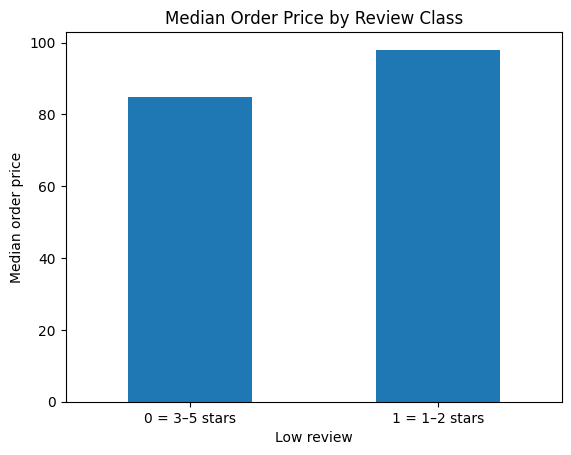

In [ ]:
median_price = (
    df_eda
    .groupby('low_review')['total_price']
    .median()
)

median_price.plot(kind='bar')

plt.title('Median Order Price by Review Class')
plt.xlabel('Low review')
plt.ylabel('Median order price')
plt.xticks(
    ticks=[0, 1],
    labels=['0 = 3–5 stars', '1 = 1–2 stars'],
    rotation=0
)
plt.show()

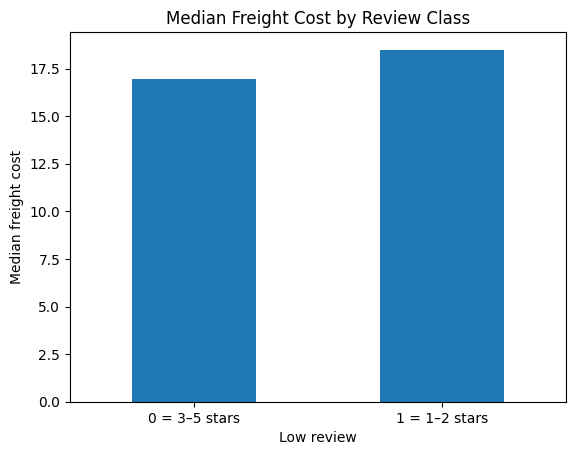

In [ ]:
median_freight = (
    df_eda
    .groupby('low_review')['total_freight']
    .median()
)

median_freight.plot(kind='bar')

plt.title('Median Freight Cost by Review Class')
plt.xlabel('Low review')
plt.ylabel('Median freight cost')
plt.xticks(
    ticks=[0, 1],
    labels=['0 = 3–5 stars', '1 = 1–2 stars'],
    rotation=0
)
plt.show()

Заказы с низкой оценкой имеют более высокую медианную стоимость заказа (98.00 против 84.90) и стоимость доставки (18.49 против 16.94). Связь присутствует, однако различия значительно менее выражены, чем для сроков доставки. Более высокие средние значения по сравнению с медианами также указывают на наличие дорогих заказов-выбросов.

## 4- Есть ли категории товаров, где низкие отзывы встречаются чаще?

In [ ]:
# 4. Есть ли категории товаров, где низкие отзывы встречаются чаще?

category_stats = (
    df_eda
    .groupby('main_product_category')
    .agg(
        orders=('order_id', 'count'),
        low_review_rate=('low_review', 'mean')
    )
    .reset_index()
)

# Переводим долю в проценты
category_stats['low_review_rate'] = (
    category_stats['low_review_rate'] * 100
)

# Оставляем категории минимум со 100 заказами
# и исключаем unknown
category_stats_filtered = (
    category_stats[
        (category_stats['orders'] >= 100) &
        (category_stats['main_product_category'] != 'unknown')
    ]
    .sort_values('low_review_rate', ascending=False)
)

# Берём топ-10
top_categories = category_stats_filtered.head(10)

top_categories[
    ['main_product_category', 'orders', 'low_review_rate']
].round(2)

,main_product_category,orders,low_review_rate
30,fashion_male_clothing,105,22.86
57,office_furniture,1242,21.90
4,audio,341,21.41
47,home_confort,379,18.21
34,fixed_telephony,209,16.75
33,fashion_underwear_beach,116,16.38
48,home_construction,470,15.96
7,bed_bath_table,9080,15.81
19,construction_tools_safety,153,15.69
39,furniture_decor,6143,14.83


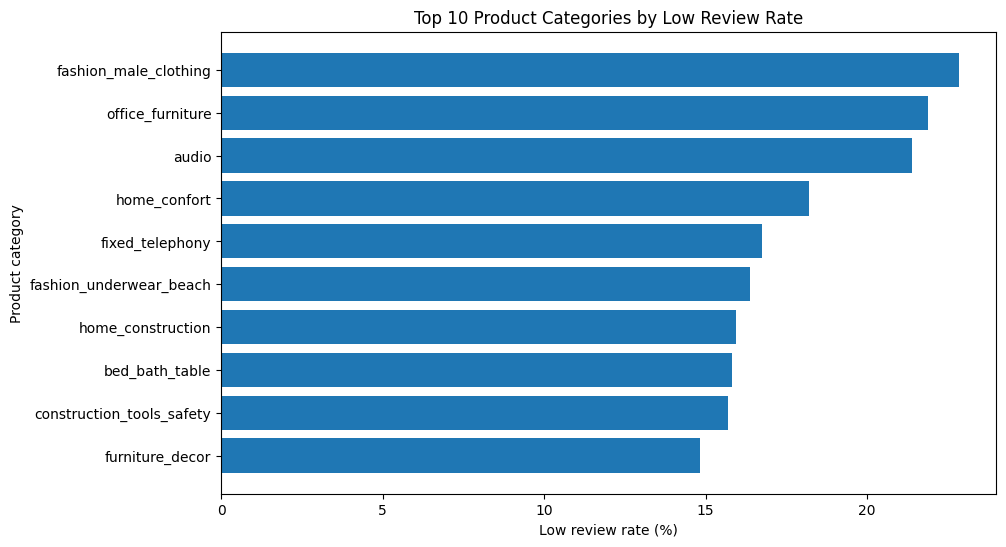

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_categories['main_product_category'],
    top_categories['low_review_rate']
)

plt.gca().invert_yaxis()

plt.title('Top 10 Product Categories by Low Review Rate')
plt.xlabel('Low review rate (%)')
plt.ylabel('Product category')

plt.show()

Доля низких оценок различается между категориями товаров. Среди категорий как минимум со 100 заказами наибольшая доля низких оценок наблюдается у fashion_male_clothing — 22.86%, office_furniture — 21.90% и audio — 21.41%. Особенно выделяется категория office_furniture: высокая доля низких оценок наблюдается на 1 242 заказах, поэтому результат основан на существенно большем объёме данных. Категория товара потенциально может быть информативным признаком для прогнозирования низкой оценки.

# Блок машинного обучения

In [ ]:
df_ml = df.copy()

In [ ]:
# удаляем колонки, которые модели не даем:
columns_to_drop = [
    'order_id',                       # уникальный ID заказа
    'review_score',                   # leakage: из него создан low_review

    'order_purchase_timestamp',       # сырые даты уже представлены delivery_days/delay_days
    'order_delivered_customer_date',
    'order_estimated_delivery_date',

    'main_product_id',                # слишком много уникальных ID
    'main_seller_id',                 # слишком много уникальных ID
    'customer_city'                   # много уникальных городов, пока не используем
]

df_ml = df_ml.drop(columns=columns_to_drop)

In [ ]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95832 entries, 0 to 95831
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_state         95832 non-null  object 
 1   delivery_days          95824 non-null  float64
 2   delay_days             95824 non-null  float64
 3   is_late                95832 non-null  int64  
 4   item_count             95832 non-null  int64  
 5   unique_products        95832 non-null  int64  
 6   unique_sellers         95832 non-null  int64  
 7   total_price            95832 non-null  float64
 8   total_freight          95832 non-null  float64
 9   main_product_category  94483 non-null  object 
 10  main_seller_state      95832 non-null  object 
 11  payment_records        95831 non-null  float64
 12  payment_type_count     95831 non-null  float64
 13  total_payment_value    95831 non-null  float64
 14  primary_payment_type   95831 non-null  object 
 15  lo

In [ ]:
df_ml.isna().sum()

,0
customer_state,0
delivery_days,8
delay_days,8
is_late,0
item_count,0
unique_products,0
unique_sellers,0
total_price,0
total_freight,0
main_product_category,1349


In [ ]:
# Разделяем данные на признаки X и целевую переменную y

X = df_ml.drop(columns='low_review')
y = df_ml['low_review']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (95832, 15)
y shape: (95832,)


In [ ]:
from sklearn.model_selection import train_test_split #делим на train and test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain target:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest target:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (76665, 15)
X_test: (19167, 15)

Train target:
low_review
0    0.872
1    0.128
Name: proportion, dtype: float64

Test target:
low_review
0    0.872
1    0.128
Name: proportion, dtype: float64


## предобработка признаков

числовые пропуски заполним медианой;
категориальные пропуски — самым частым значением;
числовые признаки масштабируем;
категориальные превратим в числа через One-Hot Encoding.

In [ ]:
# Числовые признаки
numeric_features = [
    'delivery_days',
    'delay_days',
    'is_late',
    'item_count',
    'unique_products',
    'unique_sellers',
    'total_price',
    'total_freight',
    'payment_records',
    'payment_type_count',
    'total_payment_value'
]

# Категориальные признаки
categorical_features = [
    'customer_state',
    'main_product_category',
    'main_seller_state',
    'primary_payment_type'
]

print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))

Numeric: 11
Categorical: 4


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Обработка числовых признаков
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Обработка категориальных признаков
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Объединяем обработку
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created")

Preprocessor created


## логистическая регрессия

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

In [ ]:
logreg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['delivery_days',
                                                   'delay_days', 'is_late',
                                                   'item_count',
                                                   'unique_products',
                                                   'unique_sellers',
                                                   'total_price',
                                                   'total_freight',
                                                   'payment_records',
                                                   'payment_type_count',
                                                   'total_payment_value']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['customer_state',
                                                   'main_product_category',
                                                   'main_seller_state',
                                                   'primary_payment_type'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
# Предсказания Logistic Regression

y_pred_logreg = logreg_model.predict(X_test)
y_proba_logreg = logreg_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

print(classification_report(y_test, y_pred_logreg, digits=3))

print("ROC-AUC:",
      round(roc_auc_score(y_test, y_proba_logreg), 3))

              precision    recall  f1-score   support

           0      0.928     0.854     0.889     16712
           1      0.355     0.547     0.431      2455

    accuracy                          0.815     19167
   macro avg      0.641     0.701     0.660     19167
weighted avg      0.854     0.815     0.830     19167

ROC-AUC: 0.755


Для класса 1 = low_review у Logistic Regression получилось:

- Recall = 0.547 → модель нашла 54.7% всех реально плохих отзывов.
- Precision = 0.355 → среди заказов, которые модель пометила как риск плохого отзыва, действительно плохими оказались 35.5%.
- F1 = 0.431 → баланс между precision и recall.
- ROC-AUC = 0.755 → модель достаточно неплохо разделяет более и менее рискованные заказы.

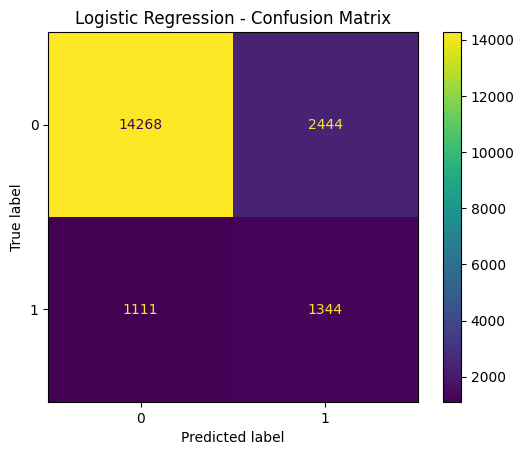

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logreg
)

plt.title('Logistic Regression - Confusion Matrix')
plt.show()

## random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

rf_model = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(y_test, y_pred_rf, digits=3))

print("ROC-AUC:",
      round(roc_auc_score(y_test, y_proba_rf), 3))

              precision    recall  f1-score   support

           0      0.905     0.983     0.942     16712
           1      0.713     0.296     0.419      2455

    accuracy                          0.895     19167
   macro avg      0.809     0.639     0.680     19167
weighted avg      0.880     0.895     0.875     19167

ROC-AUC: 0.746


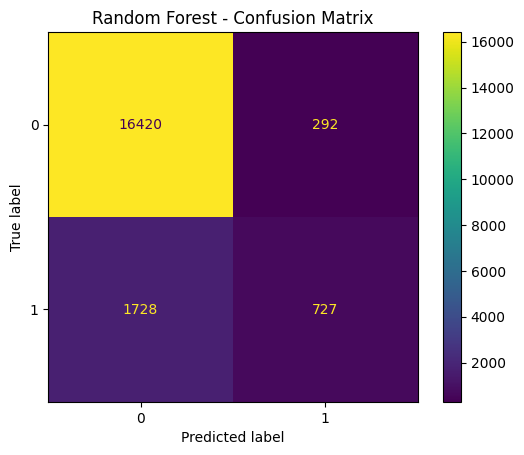

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title('Random Forest - Confusion Matrix')
plt.show()

У Random Forest для класса 1 = low_review:

- Precision = 0.713 — если RF говорит «будет плохой отзыв», он довольно часто прав.
- Recall = 0.296 — но он находит только 29.6% всех реально плохих отзывов.
- F1 = 0.419
- ROC-AUC = 0.746
- Accuracy = 89.5%, но из-за дисбаланса классов эта цифра сама по себе мало что говорит.

## сравнение метрик по моделям

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],

    'Precision': [
        precision_score(y_test, y_pred_logreg),
        precision_score(y_test, y_pred_rf)
    ],

    'Recall': [
        recall_score(y_test, y_pred_logreg),
        recall_score(y_test, y_pred_rf)
    ],

    'F1': [
        f1_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_rf)
    ],

    'ROC_AUC': [
        roc_auc_score(y_test, y_proba_logreg),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

model_comparison.round(3)

,Model,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.355,0.547,0.431,0.755
1,Random Forest,0.713,0.296,0.419,0.746


## Сравнение моделей

Logistic Regression и Random Forest показали разные свойства. Для класса низких оценок Logistic Regression получила Recall = 0.547, тогда как Random Forest — 0.296. Это означает, что Logistic Regression обнаруживает существенно большую долю реально недовольных клиентов.

Random Forest, напротив, имеет значительно более высокий Precision = 0.713 против 0.355 у Logistic Regression: его предупреждения реже оказываются ложными.

Для данной бизнес-задачи особенно важен Recall, поскольку цель состоит в том, чтобы заранее обнаружить как можно больше потенциально недовольных клиентов. Поэтому Logistic Regression может быть более подходящей базовой моделью для сценария проактивного вмешательства, несмотря на большее количество ложных срабатываний.

ROC-AUC моделей оказался близким: 0.755 для Logistic Regression и 0.746 для Random Forest. Модель достаточно хорошо различает заказы с высоким и низким риском получения плохой оценки.

- Logistic Regression → ловим больше недовольных клиентов
- Random Forest        → меньше ложных тревог, но больше пропусков

Logistic Regression
→ хороший вариант, если задача — поймать больше потенциально недовольных

Random Forest
→ хороший вариант, если бизнес хочет вмешиваться только когда уверенность выше

In [ ]:
# Получаем имена признаков после preprocessing

feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

# Получаем важности признаков из Random Forest
importances = rf_model.named_steps['classifier'].feature_importances_

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feature_importance = (
    feature_importance
    .sort_values('importance', ascending=False)
    .head(15)
)

feature_importance

,feature,importance
1,num__delay_days,0.185446
0,num__delivery_days,0.169188
10,num__total_payment_value,0.105856
7,num__total_freight,0.105346
6,num__total_price,0.099273
2,num__is_late,0.044970
3,num__item_count,0.027155
134,cat__primary_payment_type_credit_card,0.010959
133,cat__primary_payment_type_boleto,0.010103
4,num__unique_products,0.008981


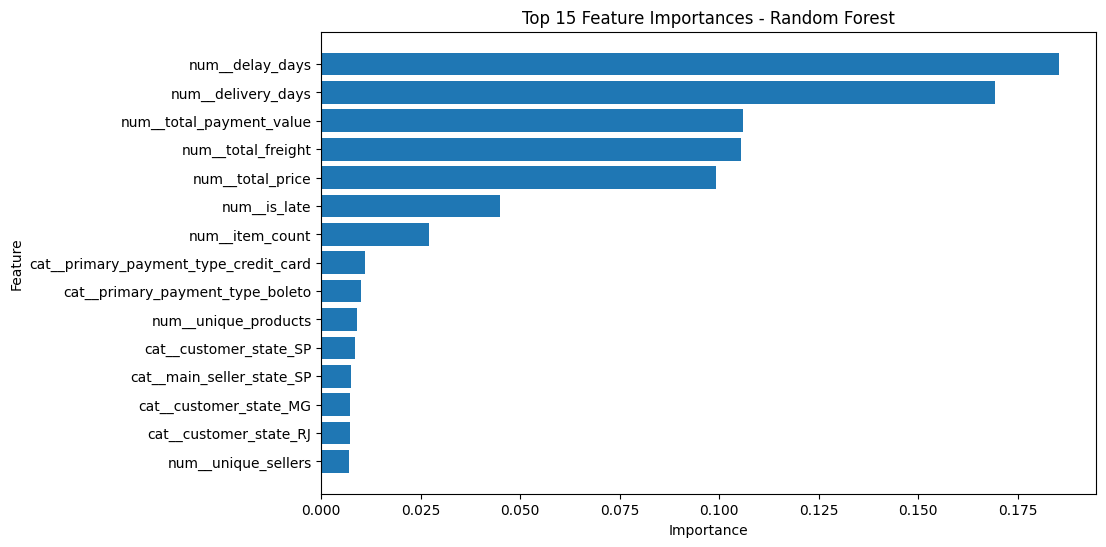

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['feature'],
    feature_importance['importance']
)

plt.gca().invert_yaxis()

plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

Самые важные признаки Random Forest:

- delay_days ≈ 0.185 — насколько доставка отклонилась от обещанной даты.
- delivery_days ≈ 0.169 — общая длительность доставки.
- total_payment_value ≈ 0.106.
- total_freight ≈ 0.105.
- total_price ≈ 0.099.
- is_late ≈ 0.045.

сроки доставки — наиболее значимая группа признаков для прогнозирования низкой оценки

Наиболее важными признаками Random Forest оказались характеристики доставки: delay_days и delivery_days. Также существенный вклад в прогноз вносят стоимость заказа, стоимость доставки и общая сумма оплаты. Это согласуется с результатами EDA, где задержка доставки была тесно связана с низкой оценкой.

## Бизнес-выводы

Цель проекта состояла в том, чтобы определить заказы с повышенным риском получения низкой оценки 1–2 звезды до того, как клиент оставит отзыв.

Анализ показал, что наиболее сильная связь с низкой оценкой наблюдается у характеристик доставки. Среди заказов, доставленных вовремя, доля низких оценок составила 9.22%, тогда как среди опоздавших заказов — 54.07%. Заказы с низкой оценкой также доставлялись в среднем дольше.

Random Forest подтвердил важность логистических факторов: наиболее значимыми признаками оказались delay_days и delivery_days. Существенный вклад также вносили стоимость заказа, стоимость доставки и общая сумма оплаты.

Доля низких оценок различалась и между товарными категориями. Например, среди категорий минимум со 100 заказами повышенная доля низких оценок наблюдалась у fashion_male_clothing, office_furniture и audio.

Следовательно, Olist потенциально может использовать модель как инструмент раннего выявления рискованных заказов. Для заказов с высоким прогнозируемым риском можно рассматривать проактивные действия: дополнительное информирование клиента о задержке, проверку статуса доставки, обращение службы поддержки или компенсационные меры.

## Ограничения проекта

- Модель построена на исторических данных Olist за ограниченный период, поэтому её качество на новых данных необходимо проверять отдельно.
- Feature importance показывает предсказательную полезность признаков, но не доказывает причинно-следственную связь.
- Для многотоварных заказов в качестве основного товара использовался самый дорогой товар — это упрощение.
- Текст отзывов не использовался, поскольку NLP не входит в рамки проекта.
- Модель использует данные, известные к моменту фактической доставки. Поэтому delivery_days, delay_days и is_late допустимы в нашей постановке, но такая модель предназначена для вмешательства после доставки и до оставления отзыва, а не для прогноза ещё в момент оформления заказа.
- Порог классификации 0.5 пока использован стандартный. В реальном бизнесе его можно настраивать в зависимости от стоимости ложного срабатывания и стоимости пропущенного недовольного клиента.

In [ ]:
!python --version

Python 3.13.15
